In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("test.csv")

   profile pic  nums/length username  fullname words  nums/length fullname  \
0            1                  0.33               1                  0.33   
1            1                  0.00               5                  0.00   
2            1                  0.00               2                  0.00   
3            1                  0.00               1                  0.00   
4            1                  0.50               1                  0.00   

   name==username  description length  external URL  private  #posts  \
0               1                  30             0        1      35   
1               0                  64             0        1       3   
2               0                  82             0        1     319   
3               0                 143             0        1     273   
4               0                  76             0        1       6   

   #followers  #follows  fake  
0         488       604     0  
1          35         6     0  
2 

In [5]:
print(df.head(5))

   profile pic  nums/length username  fullname words  nums/length fullname  \
0            1                  0.33               1                  0.33   
1            1                  0.00               5                  0.00   
2            1                  0.00               2                  0.00   
3            1                  0.00               1                  0.00   
4            1                  0.50               1                  0.00   

   name==username  description length  external URL  private  #posts  \
0               1                  30             0        1      35   
1               0                  64             0        1       3   
2               0                  82             0        1     319   
3               0                 143             0        1     273   
4               0                  76             0        1       6   

   #followers  #follows  fake  
0         488       604     0  
1          35         6     0  
2 

In [6]:
print(df.shape)

(120, 12)


In [7]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           120 non-null    int64  
 1   nums/length username  120 non-null    float64
 2   fullname words        120 non-null    int64  
 3   nums/length fullname  120 non-null    float64
 4   name==username        120 non-null    int64  
 5   description length    120 non-null    int64  
 6   external URL          120 non-null    int64  
 7   private               120 non-null    int64  
 8   #posts                120 non-null    int64  
 9   #followers            120 non-null    int64  
 10  #follows              120 non-null    int64  
 11  fake                  120 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 11.4 KB
None
       profile pic  nums/length username  fullname words  \
count   120.000000            120.000000      120.000000   
mean

In [8]:
print(df.isnull().sum())

profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64


In [9]:
X = df.drop('fake', axis=1)

print(X.head())

   profile pic  nums/length username  fullname words  nums/length fullname  \
0            1                  0.33               1                  0.33   
1            1                  0.00               5                  0.00   
2            1                  0.00               2                  0.00   
3            1                  0.00               1                  0.00   
4            1                  0.50               1                  0.00   

   name==username  description length  external URL  private  #posts  \
0               1                  30             0        1      35   
1               0                  64             0        1       3   
2               0                  82             0        1     319   
3               0                 143             0        1     273   
4               0                  76             0        1       6   

   #followers  #follows  
0         488       604  
1          35         6  
2         328       

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[ 0.56451866  0.62408897 -0.46525043 ... -0.20856404 -0.12922167
  -0.12487838]
 [ 0.56451866 -0.74814442  2.91838905 ... -0.34799404 -0.13041371
  -0.5509564 ]
 [ 0.56451866 -0.74814442  0.38065944 ...  1.02887722 -0.1296427
  -0.07927806]
 ...
 [ 0.56451866 -0.74814442  0.38065944 ... -0.34799404 -0.12831382
   1.98983658]
 [-1.77142063 -0.04123631 -0.46525043 ... -0.35670842 -0.12992953
   0.65246462]
 [ 0.56451866  1.0815001  -0.46525043 ... -0.34799404 -0.13040319
  -0.50678109]]


In [11]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df['Cluster'].value_counts())

Cluster
-1    40
 1    31
 0    30
 2    19
Name: count, dtype: int64


In [12]:
print(df[['fake','Cluster']].head(20))

    fake  Cluster
0      0       -1
1      0       -1
2      0        0
3      0       -1
4      0        0
5      0        0
6      0        0
7      0        0
8      0        0
9      0        0
10     0        0
11     0       -1
12     0        0
13     0        0
14     0        1
15     0        0
16     0        0
17     0        0
18     0       -1
19     0        0


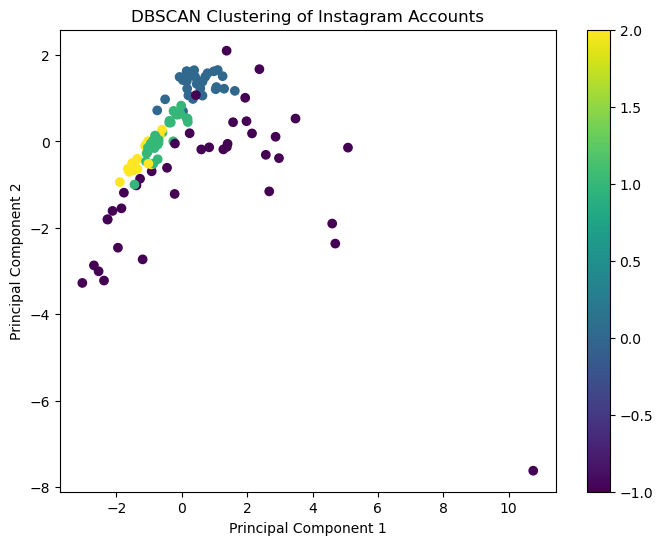

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("DBSCAN Clustering of Instagram Accounts")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar()

plt.show()

In [14]:
print(pd.crosstab(df['fake'], df['Cluster']))

Cluster  -1   0   1   2
fake                   
0        19  30  11   0
1        21   0  20  19


In [15]:
outliers = df[df['Cluster'] == -1]

print("Suspicious Accounts:")
print(outliers.head())

Suspicious Accounts:
    profile pic  nums/length username  fullname words  nums/length fullname  \
0             1                  0.33               1                  0.33   
1             1                  0.00               5                  0.00   
3             1                  0.00               1                  0.00   
11            1                  0.14               1                  0.00   
18            1                  0.00               3                  0.00   

    name==username  description length  external URL  private  #posts  \
0                1                  30             0        1      35   
1                0                  64             0        1       3   
3                0                 143             0        1     273   
11               0                  78             1        1      97   
18               0                  46             0        1     590   

    #followers  #follows  fake  Cluster  
0          488       60

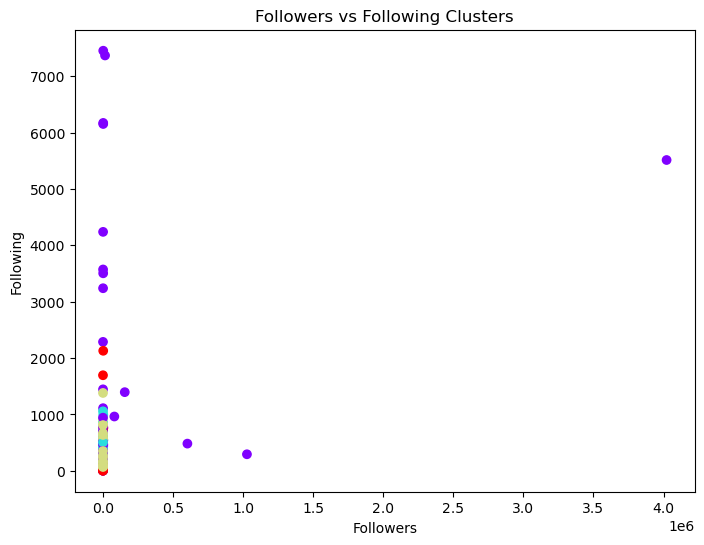

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['#followers'],
    df['#follows'],
    c=df['Cluster'],
    cmap='rainbow'
)

plt.xlabel("Followers")
plt.ylabel("Following")
plt.title("Followers vs Following Clusters")

plt.show()